In [1]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127

In [11]:
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml
import os
import pandas as pd
import cv2
import glob

In [3]:
### YoloV8:

from roboflow import Roboflow
rf = Roboflow(api_key="V12deDQVnSZqs4PkLX0Y")
project = rf.workspace("human-detection-vvi7i").project("object_detection_room")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to object_detection_room-1 in yolov8:: 100%|██████████| 412/412 [00:00<00:00, 8637.03it/s]


In [4]:
# Load YOLOv8n model
model = YOLO('yolov8s.pt')

# Train the model and validate using the val set
results = model.train(
    data='/content/object_detection_room-1/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,  # early stopping based on val loss
    val=True,     # ensure validation is done during training
    verbose=True
)


100%|██████████| 21.5M/21.5M [00:00<00:00, 148MB/s]


Ultralytics 8.3.152 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/object_detection_room-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12

100%|██████████| 755k/755k [00:00<00:00, 24.1MB/s]

Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              


  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1838080  ultralytics.nn.modules.block.C2f             [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    591360  ultralytics.nn.modules.block.C2f             [768, 256, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]  

...

     65/100      3.92G      1.041     0.5751      1.145         14        640: 100%|██████████| 9/9 [00:02<00:00,  3.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  5.21it/s]

                   all         40         20      0.964          1      0.995      0.739
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 45, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



65 epochs completed in 0.065 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 22.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.152 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  5.66it/s]


                   all         40         20      0.923          1      0.995      0.768
                   bag          4          4      0.796          1      0.995      0.804
                   fan         11         11      0.982          1      0.995      0.765
                laptop          5          5       0.99          1      0.995      0.734
Speed: 0.3ms preprocess, 4.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train


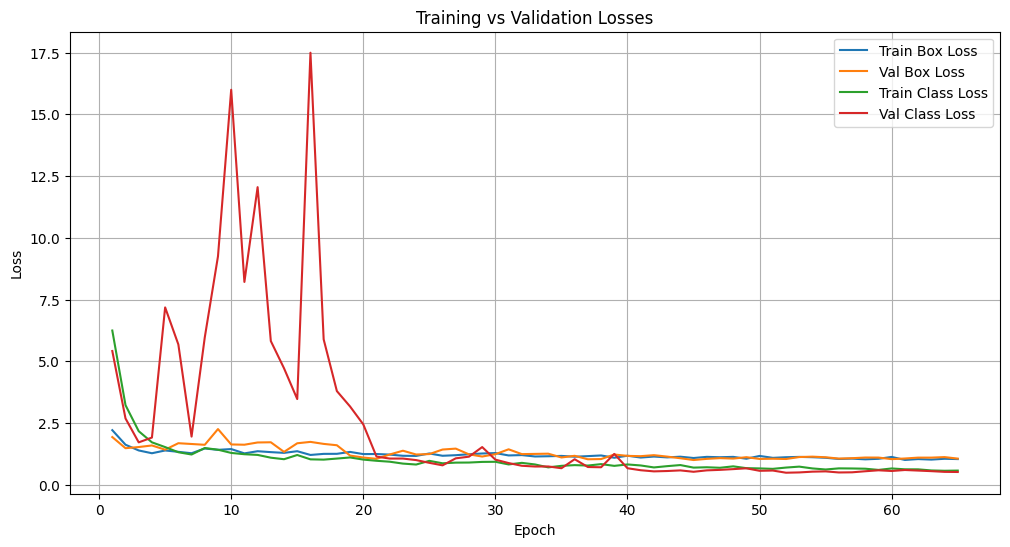

In [5]:
# Find latest run folder
run_dir = sorted([f for f in os.listdir('runs/detect') if not f.startswith('.')])[-1]
results_path = f'runs/detect/{run_dir}/results.csv'

# Plot train and val loss
df = pd.read_csv(results_path)

plt.figure(figsize=(12, 6))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Losses')
plt.legend()
plt.grid()
plt.show()

In [6]:
# Evaluate on test set
metrics = model.val(split='test')
print(metrics.names)

Ultralytics 8.3.152 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1274.8±336.0 MB/s, size: 43.9 KB)


val: Scanning /content/object_detection_room-1/test/labels... 20 images, 12 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<00:00, 3005.05it/s]

val: New cache created: /content/object_detection_room-1/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.83it/s]


                   all         20         10      0.903          1      0.995      0.792
                   bag          3          3      0.985          1      0.995      0.816
                   fan          5          5      0.741          1      0.995      0.811
                laptop          2          2      0.984          1      0.995      0.748
Speed: 4.7ms preprocess, 14.9ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/train2
{0: 'bag', 1: 'fan', 2: 'laptop'}



image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0011_jpg.rf.46de4e3321c138917fc888b58fb99abe.jpg: 640x640 1 fan, 16.3ms
Speed: 2.2ms preprocess, 16.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


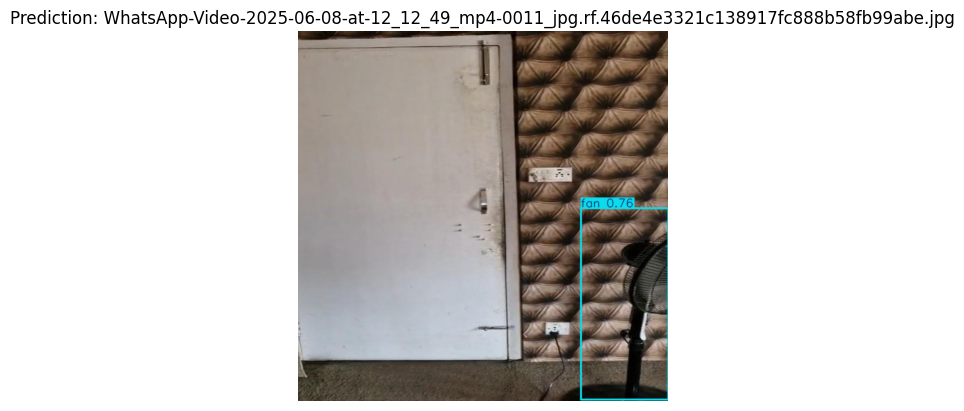


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0012_jpg.rf.41ddf2122231f3b38c1a6017e4a78e5a.jpg: 640x640 2 fans, 16.4ms
Speed: 3.1ms preprocess, 16.4ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


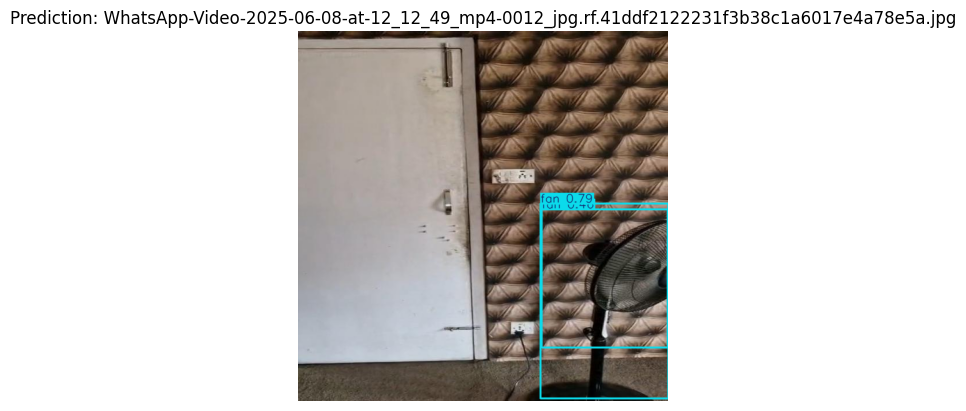


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0013_jpg.rf.df8097690ad00a1df54ee7b524f549b1.jpg: 640x640 1 fan, 17.0ms
Speed: 3.0ms preprocess, 17.0ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


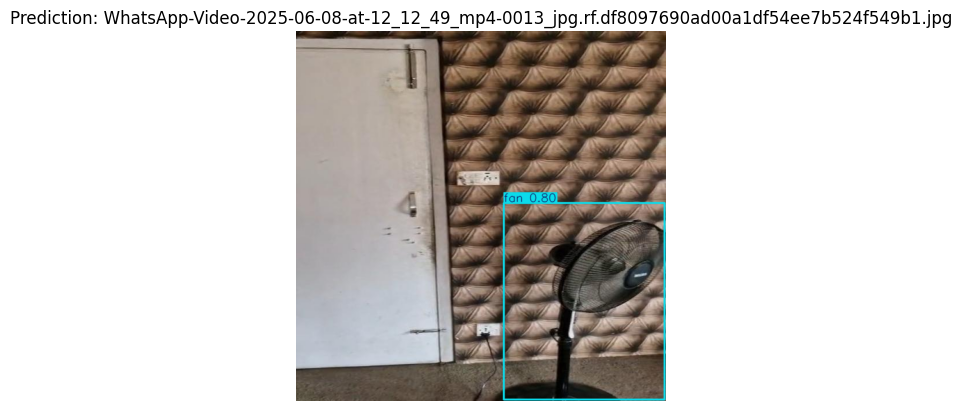


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0016_jpg.rf.835f1d93cf2c0d44dc18e0e22846ada2.jpg: 640x640 1 fan, 17.0ms
Speed: 2.9ms preprocess, 17.0ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


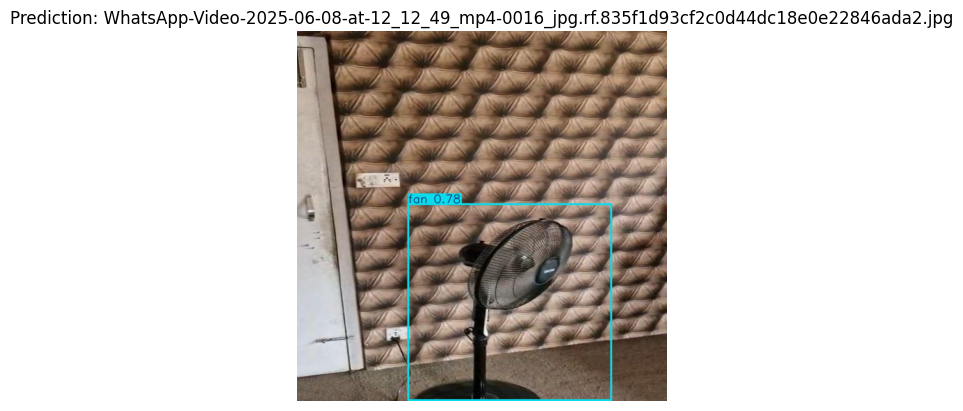


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0027_jpg.rf.1e15ed11286af0899e84e4a96f4b9bc1.jpg: 640x640 1 fan, 16.4ms
Speed: 2.8ms preprocess, 16.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


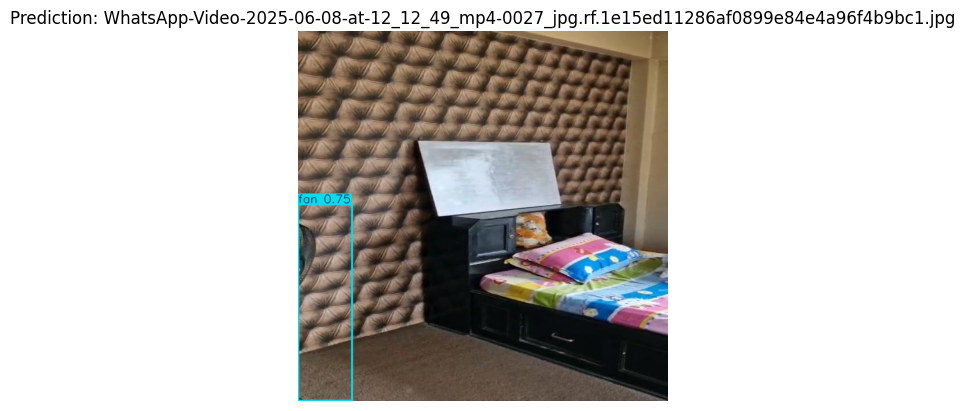


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0033_jpg.rf.e09a4642eb772cdc7493485c72fc5cab.jpg: 640x640 (no detections), 16.4ms
Speed: 2.8ms preprocess, 16.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


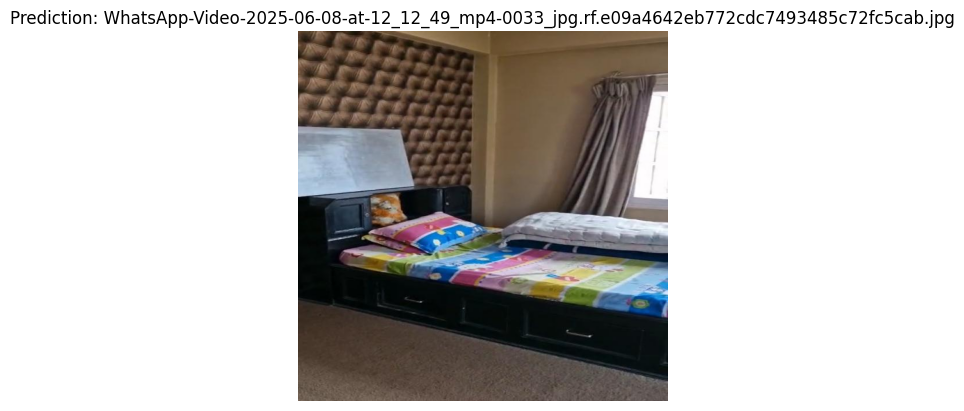


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0049_jpg.rf.bedc0728e6d950bdb38c4805007352ca.jpg: 640x640 1 bag, 1 laptop, 16.5ms
Speed: 3.9ms preprocess, 16.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


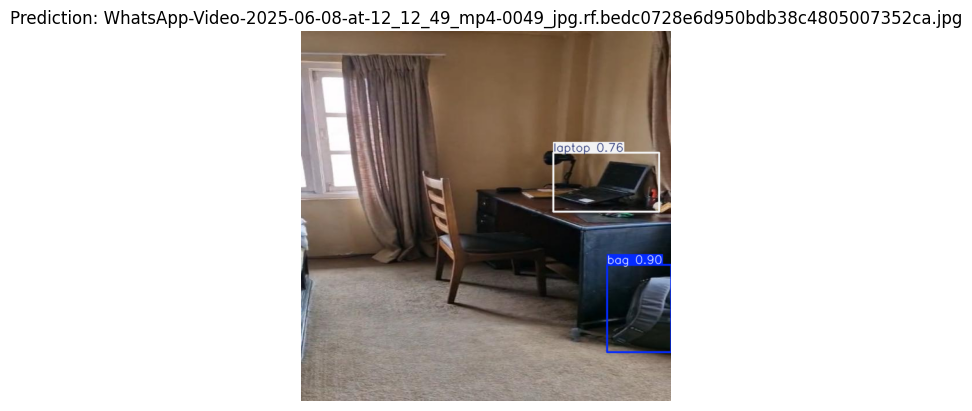


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0062_jpg.rf.b45c16ae32a959bfac7ee3477fe46060.jpg: 640x640 1 bag, 16.4ms
Speed: 4.7ms preprocess, 16.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


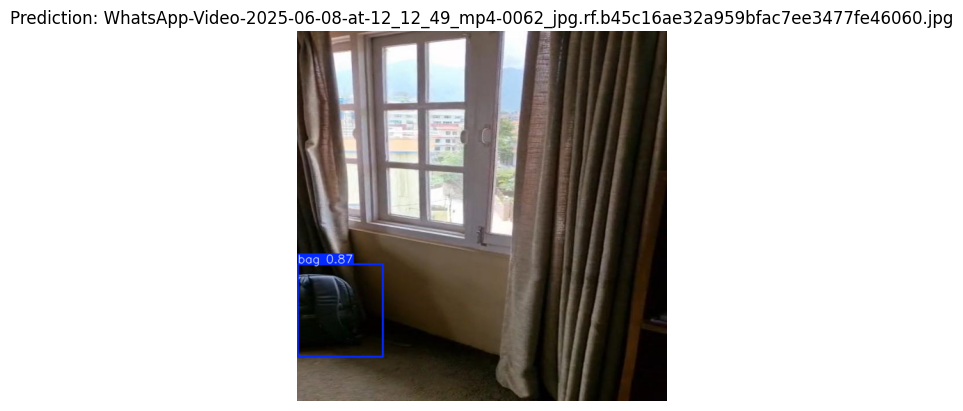


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0064_jpg.rf.d601323eb689267982ccc789a813a42a.jpg: 640x640 1 bag, 16.4ms
Speed: 2.6ms preprocess, 16.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


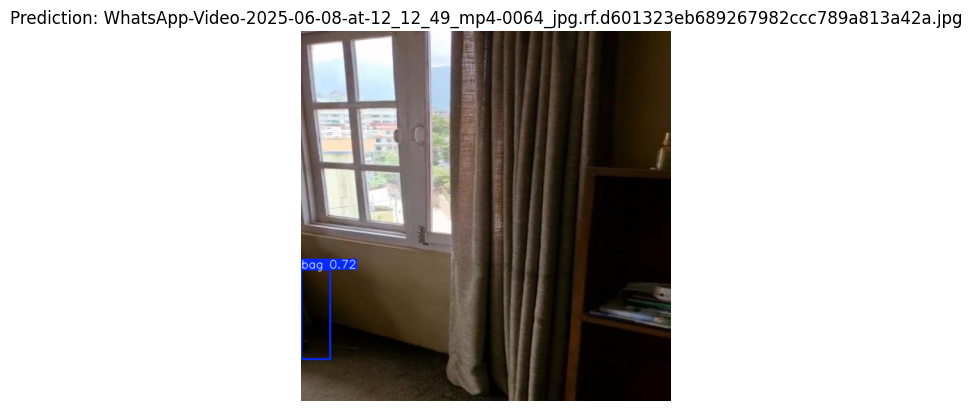


image 1/1 /content/object_detection_room-1/test/images/WhatsApp-Video-2025-06-08-at-12_12_49_mp4-0067_jpg.rf.3196604479d0a931548c5a28a26dfff7.jpg: 640x640 (no detections), 16.4ms
Speed: 3.0ms preprocess, 16.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


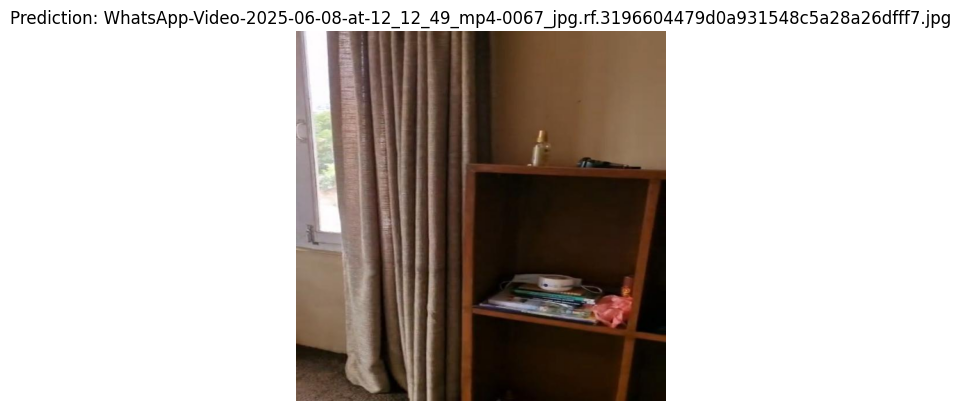

In [10]:
# Path to your test images
test_images = sorted(glob.glob('/content/object_detection_room-1/test/images/*.jpg'))[:10]
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Predict and show results
for img_path in test_images:
    results = model(img_path)  # returns list of Results objects
    annotated_frame = results[0].plot()  # draw boxes
    # Convert from BGR to RGB for matplotlib
    rgb_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.title(f"Prediction: {img_path.split('/')[-1]}")
    plt.axis('off')
    plt.show()
